In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load the cleaned dataset
df = pd.read_csv("../data/SaleCleanForAnalysis.csv")

df.head()

,longitude,latitude,transaction_type,price,property_type,property_subtype,seller_id,postal_code,date_of_construction,property_condition,...,availability,province,street,street_number,garage,land_surface,energy_consumption,garden,balcony,swimming_pool
0,4.387667,50.846952,Sale,395000,Appartment,Duplex,46453,1000,1900.0,Excellent,...,On contract,Brussels,rue des patriotes,9.0,NaN,NaN,NaN,NaN,NaN,NaN
1,4.376693,50.823572,Sale,465000,Appartment,Flat,44165,1050,1959.0,Fully renovated,...,On contract,Brussels,rdpt de l'etoile,5.0,NaN,NaN,12178.0,NaN,NaN,NaN
2,4.341528,50.810316,Sale,190000,Appartment,Flat,46535,1180,NaN,To be renovated,...,Immediately,Brussels,rue des glaïeuls,17.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4.333333,50.800000,Sale,155000,Appartment,FlatStudio,48985,1180,1978.0,Excellent,...,NaN,Brussels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.400549,50.850183,Sale,329000,Appartment,Flat,46371,1030,1959.0,Normal,...,NaN,Brussels,avenue lacomblé,14.0,1.0,NaN,NaN,NaN,True,NaN


In [2]:
# display the dataset information and summary statistics
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   longitude             9709 non-null   float64
 1   latitude              9709 non-null   float64
 2   transaction_type      9712 non-null   str    
 3   price                 9712 non-null   int64  
 4   property_type         9712 non-null   str    
 5   property_subtype      9712 non-null   str    
 6   seller_id             9712 non-null   int64  
 7   postal_code           9712 non-null   int64  
 8   date_of_construction  6280 non-null   float64
 9   property_condition    7516 non-null   str    
 10  livable_surface       9154 non-null   float64
 11  number_of_bedrooms    9537 non-null   float64
 12  number_of_bathrooms   8780 non-null   float64
 13  elevator              7164 non-null   object 
 14  terrace               3670 non-null   float64
 15  furnished             5954 non-n

,longitude,latitude,price,seller_id,postal_code,date_of_construction,livable_surface,number_of_bedrooms,number_of_bathrooms,terrace,street_number,garage,land_surface,energy_consumption,garden
count,9709.000000,9709.000000,9.712000e+03,9712.000000,9712.000000,6280.000000,9154.000000,9537.000000,8780.000000,3670.000000,7688.000000,3493.000000,5636.000000,2423.000000,2412.000000
mean,4.587202,50.713370,4.038680e+05,37963.192236,4757.587315,1970.905732,169.400371,3.076125,1.387472,27.903542,73.518470,1.237332,1371.521114,53853.146925,997.560945
std,0.766890,0.378155,3.775355e+05,10444.316928,2718.506319,46.719683,116.880618,1.849597,0.918840,36.067537,523.744943,0.646661,4256.320333,48773.353880,3525.050758
min,2.576453,47.512679,0.000000e+00,0.000000,1000.000000,1554.000000,13.000000,0.000000,1.000000,1.000000,0.000000,1.000000,5.000000,1000.000000,1.000000
25%,4.239020,50.483333,2.299998e+05,33494.000000,2100.000000,1950.000000,99.000000,2.000000,1.000000,10.000000,11.000000,1.000000,256.000000,22911.500000,110.000000
50%,4.494500,50.765394,3.290000e+05,40435.500000,4500.000000,1975.000000,146.000000,3.000000,1.000000,20.000000,30.000000,1.000000,572.500000,44019.000000,338.500000
75%,5.231795,50.988216,4.650000e+05,44773.000000,6940.000000,2008.000000,200.750000,4.000000,2.000000,34.000000,74.000000,1.000000,1180.000000,72040.000000,833.250000
max,6.353742,51.472440,1.300000e+07,49351.000000,9991.000000,2028.000000,1565.000000,100.000000,23.000000,734.000000,40104.000000,10.000000,96317.000000,911959.000000,80000.000000


In [3]:
# check for missing values in the dataset
df.isna().sum()
df.isna().sum().sort_values(ascending=False)

balcony                 8693
swimming_pool           8370
garden                  7300
energy_consumption      7289
garage                  6219
terrace                 6042
availability            4387
land_surface            4076
furnished               3758
date_of_construction    3432
elevator                2548
property_condition      2196
street_number           2024
street                  1828
number_of_bathrooms      932
livable_surface          558
number_of_bedrooms       175
latitude                   3
longitude                  3
postal_code                0
seller_id                  0
property_subtype           0
price                      0
transaction_type           0
property_type              0
province                   0
dtype: int64

In [4]:
# check for unique values in each column
df.nunique()


longitude               7513
latitude                7494
transaction_type           1
price                   1389
property_type              2
property_subtype          15
seller_id                849
postal_code              897
date_of_construction     181
property_condition         9
livable_surface          555
number_of_bedrooms        25
number_of_bathrooms       15
elevator                   2
terrace                  137
furnished                  2
availability              64
province                  11
street                  5268
street_number            460
garage                     7
land_surface            2014
energy_consumption      2295
garden                   866
balcony                    2
swimming_pool              2
dtype: int64

In [5]:
# check the shape of the dataset
df.shape

(9712, 26)

In [6]:
# drop unnecessary columns
columns_to_drop = [
    "seller_id",
    "transaction_type",
    "street",
    "street_number",
    "postal_code",
    "balcony",
    "swimming_pool",
    "availability",
    "furnished",
    "energy_consumption",
    "garden",
    "terrace",
    "garage"
]
df = df.drop(columns=columns_to_drop)

In [7]:
df.columns

Index(['longitude', 'latitude', 'price', 'property_type', 'property_subtype',
       'date_of_construction', 'property_condition', 'livable_surface',
       'number_of_bedrooms', 'number_of_bathrooms', 'elevator', 'province',
       'land_surface'],
      dtype='str')

In [8]:
df.shape

(9712, 13)

In [9]:
# define X = property information, y = price
X = df.drop(columns="price")
y = df["price"]

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns # numerical columns that have numbers
categorical_columns = X.select_dtypes(include=["object"]).columns # categorical columns that need to be encoded

print("Numerical:")
print(numerical_columns)

print("\nCategorical:")
print(categorical_columns)


Numerical:
Index(['longitude', 'latitude', 'date_of_construction', 'livable_surface',
       'number_of_bedrooms', 'number_of_bathrooms', 'land_surface'],
      dtype='str')

Categorical:
Index(['property_type', 'property_subtype', 'property_condition', 'elevator',
       'province'],
      dtype='str')


/var/folders/hb/2_z2t49j1t592qs0pm6bctlr0000gn/T/ipykernel_1190/2978205713.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns # categorical columns that need to be encoded


In [10]:
# split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7769, 12)
X_test : (1943, 12)
y_train: (7769,)
y_test : (1943,)


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# create a pipeline for numerical and categorical features
numerical_pipeline = Pipeline([
    ("fill_nan", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# create a pipeline for categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# create a preprocessor that applies the numerical and categorical pipelines to the appropriate columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ]
)

# fit the preprocessor to the training data and transform both the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(X_train_processed.shape)
print(X_test_processed.shape)


(7769, 46)
(1943, 46)


In [12]:
# get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__longitude', 'num__latitude', 'num__date_of_construction',
       'num__livable_surface', 'num__number_of_bedrooms',
       'num__number_of_bathrooms', 'num__land_surface',
       'cat__property_type_Appartment', 'cat__property_type_House',
       'cat__property_subtype_Bungalow', 'cat__property_subtype_Chalet',
       'cat__property_subtype_Cottage', 'cat__property_subtype_Duplex',
       'cat__property_subtype_Flat', 'cat__property_subtype_FlatStudio',
       'cat__property_subtype_GroundFloor', 'cat__property_subtype_House',
       'cat__property_subtype_Loft', 'cat__property_subtype_Mansion',
       'cat__property_subtype_MasterHouse',
       'cat__property_subtype_MixedBuilding',
       'cat__property_subtype_Penthouse', 'cat__property_subtype_Triplex',
       'cat__property_subtype_Villa', 'cat__property_condition_Excellent',
       'cat__property_condition_Fully renovated',
       'cat__property_condition_New', 'cat__property_condition_Normal',
       'cat__property_

In [13]:
#Calculate outliers using IQR method
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("lower_bound:", lower_bound)
print("upper_bound:", upper_bound)

#count the number of outliers
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print("Number of outliers:", outliers.shape[0]) 

# Inspect the outliers
outliers[["price"]].sort_values("price", ascending=False).head(10)


lower_bound: -122500.625
upper_bound: 817500.375
Number of outliers: 607


,price
786,13000000
2803,8994000
4907,8000000
760,7750000
5046,6450000
5368,6450000
3389,5900000
1972,5500000
688,5000000
5096,4980000


In [14]:
df["price"]

print("Above €2M:", (df["price"] > 2_000_000).sum())
print("Above €3M:", (df["price"] > 3_000_000).sum())
print("Above €5M:", (df["price"] > 5_000_000).sum())

Above €2M: 53
Above €3M: 15
Above €5M: 8


In [15]:
X_train.head()

,longitude,latitude,property_type,property_subtype,date_of_construction,property_condition,livable_surface,number_of_bedrooms,number_of_bathrooms,elevator,province,land_surface
6889,3.908370,50.749696,House,House,1989.0,Normal,194.0,3.0,1.0,NaN,Oost vlaanderen,3912.0
3469,5.340006,50.287569,Appartment,GroundFloor,NaN,NaN,280.0,5.0,2.0,False,Namur,NaN
3533,4.448089,50.387973,House,House,NaN,Fully renovated,120.0,3.0,1.0,NaN,Hainaut,175.0
5786,5.264095,51.116890,Appartment,Penthouse,2024.0,New,86.0,2.0,1.0,True,Limburg,NaN
7550,5.091508,49.916763,House,House,1918.0,To be renovated,150.0,3.0,1.0,False,Luxembourg,883.0


In [16]:
# Investigate luxury properties

for limit in [1_000_000, 2_000_000, 3_000_000, 5_000_000]:
    count = (df["price"] > limit).sum()
    percentage = count / len(df) * 100

    print(f"Above €{limit:,}: {count} houses ({percentage:.2f}%)")

Above €1,000,000: 329 houses (3.39%)
Above €2,000,000: 53 houses (0.55%)
Above €3,000,000: 15 houses (0.15%)
Above €5,000,000: 8 houses (0.08%)


In [17]:
df[df["price"] > 2_000_000][[
    "price",
    "property_type",
    "property_subtype",
    "province",
    "livable_surface",
    "number_of_bedrooms"
]].sort_values("price", ascending=False)

,price,property_type,property_subtype,province,livable_surface,number_of_bedrooms
786,13000000,House,House,Brussels,NaN,100.0
2803,8994000,House,MixedBuilding,Namur,NaN,NaN
4907,8000000,House,Mansion,Brabant wallon,NaN,4.0
760,7750000,House,House,Brussels,NaN,25.0
5368,6450000,House,Villa,Brabant wallon,1200.0,5.0
5046,6450000,House,Villa,Brabant wallon,1280.0,6.0
3389,5900000,House,House,Namur,1025.0,7.0
1972,5500000,House,Villa,Vlaams brabant,900.0,7.0
688,5000000,House,MasterHouse,Brussels,NaN,4.0
5096,4980000,House,House,Brabant wallon,1190.0,6.0


In [18]:
df[df["price"] > 5_000_000][[
    "price",
    "property_type",
    "property_subtype",
    "province",
    "livable_surface",
    "number_of_bedrooms",
    "number_of_bathrooms",
    "land_surface"
]].sort_values("price", ascending=False)

,price,property_type,property_subtype,province,livable_surface,number_of_bedrooms,number_of_bathrooms,land_surface
786,13000000,House,House,Brussels,NaN,100.0,NaN,NaN
2803,8994000,House,MixedBuilding,Namur,NaN,NaN,NaN,NaN
4907,8000000,House,Mansion,Brabant wallon,NaN,4.0,NaN,45878.0
760,7750000,House,House,Brussels,NaN,25.0,NaN,NaN
5368,6450000,House,Villa,Brabant wallon,1200.0,5.0,6.0,13154.0
5046,6450000,House,Villa,Brabant wallon,1280.0,6.0,6.0,13154.0
3389,5900000,House,House,Namur,1025.0,7.0,6.0,16677.0
1972,5500000,House,Villa,Vlaams brabant,900.0,7.0,7.0,15000.0


In [19]:
df[df["price"] >= 8_000_000]

print("Above €8M:", (df["price"] >= 8_000_000).sum())
    
df = df[df["price"] < 8_000_000].reset_index(drop=True)

print("Below €8M:", (df["price"] < 8_000_000).sum())

# Redefine X and y after removing outliers
X = df.drop(columns="price")
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Above €8M: 3
Below €8M: 9709


In [20]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [21]:
# The Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_processed, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](46,)","[ 14938.53, 33770.77, 24918.19,...,-10959.59, 80682.81, 15918.97]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.823e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,46


In [22]:
y_pred = model.predict(X_test_processed)


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# evaluate the model
mae = mean_absolute_error(y_test, y_pred) #mean absolute error; average prediction error
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) #root mean squared error; average prediction error
r2 = r2_score(y_test, y_pred) #the price variation the model explains

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 115233.0081213412
RMSE: 216956.26138897336
R²: 0.5758475730574892


In [24]:
import pandas as pd

# create a DataFrame to compare actual and predicted prices for the first 5 test samples
comparison = pd.DataFrame({
    "Actual Price": y_test.iloc[:5].values,
    "Predicted Price": y_pred[:5]
})

comparison

,Actual Price,Predicted Price
0,215000,6.225971e+04
1,394000,3.799127e+05
2,393000,3.751206e+05
3,195000,2.174693e+05
4,1850000,1.626432e+06


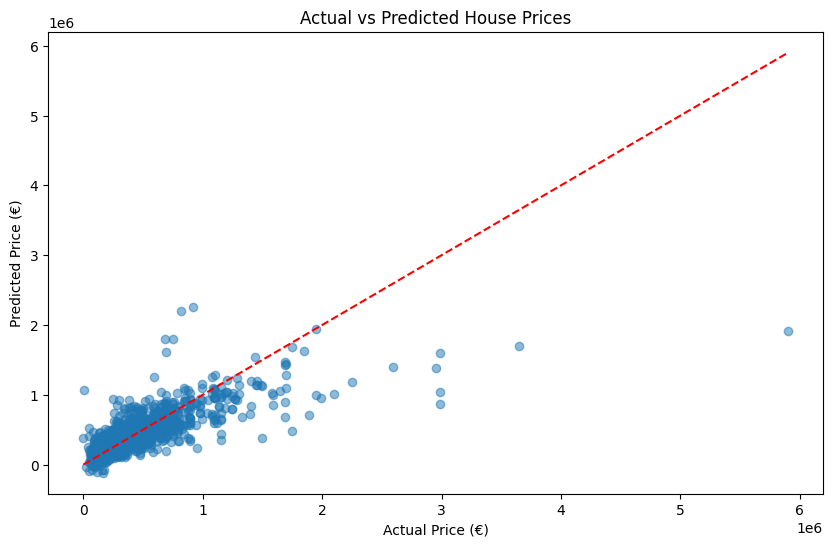

In [25]:
# visualisation of linear regression results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color="red", linestyle="--")

plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [26]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_processed, y_train)

#predicting the target variable for the test set
rf_y_pred = rf_regressor.predict(X_test_processed)

# evaluate the model
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
rf_r2 = r2_score(y_test, rf_y_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)



Random Forest
MAE: 87523.46174471542
RMSE: 184354.60878503416
R²: 0.693743314556694


In [27]:
# Train the random forest regressor
rf_train_pred = rf_regressor.predict(X_train_processed)

rf_train_r2 = r2_score(y_train, rf_train_pred)

print("Training R²:", rf_train_r2)
print("Test R²:", rf_r2)

Training R²: 0.9570305965926295
Test R²: 0.693743314556694


In [28]:
df["price"].describe()

count    9.709000e+03
mean     4.009035e+05
std      3.356787e+05
min      0.000000e+00
25%      2.299990e+05
50%      3.290000e+05
75%      4.650000e+05
max      7.750000e+06
Name: price, dtype: float64

In [29]:
#Cross-validation to assess the model's performance and generalization ability
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", np.mean(cv_scores))
print("Std CV R²:", np.std(cv_scores))

CV R² scores: [0.40896525 0.63375247 0.65571806 0.35209872 0.59833969]
Mean CV R²: 0.5297748372304081
Std CV R²: 0.1245294675997618


In [30]:
# The Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt_regressor = DecisionTreeRegressor(random_state=42)

dt_regressor.fit(X_train_processed, y_train)

dt_train_r2 = dt_regressor.score(X_train_processed, y_train)
dt_test_r2 = dt_regressor.score(X_test_processed, y_test)

dt_mae = mean_absolute_error(y_test, dt_regressor.predict(X_test_processed))
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_regressor.predict(X_test_processed)))

print("Decision Tree Regressor")
print("Training R²:", dt_train_r2)
print("Test R²:", dt_test_r2)
print("Test MAE:", dt_mae)
print("Test RMSE:", dt_rmse)

Decision Tree Regressor
Training R²: 0.9999495783626937
Test R²: 0.30330431234522726
Test MAE: 124566.85830758668
Test RMSE: 278056.32050319336


In [31]:
# compare the performance of Linear Regression, Random Forest Regressor and Decision Tree Regressor
comparison_metrics = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Decision Tree"],
    "MAE": [mae, rf_mae, dt_mae],
    "RMSE": [rmse, rf_rmse, dt_rmse],
    "R²": [r2, rf_r2, dt_test_r2]
})      

print(comparison_metrics)


               Model            MAE           RMSE        R²
0  Linear Regression  115233.008121  216956.261389  0.575848
1      Random Forest   87523.461745  184354.608785  0.693743
2      Decision Tree  124566.858308  278056.320503  0.303304


In [36]:
# Save the trained models using joblib

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(LinearRegression(), "../models/linear_regression_model.joblib")
joblib.dump(RandomForestRegressor(), "../models/random_forest_model.joblib")
joblib.dump(DecisionTreeRegressor(), "../models/decision_tree_model.joblib")

['../models/decision_tree_model.joblib']

# Conclusion

In this project,  built and compared three regression models to predict real estate prices in Belgium: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

The Random Forest model gave the best overall performance. After removing suspicious extreme properties priced above €8M, the model improved significantly, with a better test R² and lower RMSE.

The Decision Tree showed stronger overfitting, while Linear Regression was too simple for this dataset.

Cross-validation showed that the Random Forest performance is not perfectly stable, meaning the dataset is still difficult and contains variation that the model cannot fully explain.

Overall, Random Forest is the best model among the three, but further improvements could come from better feature engineering, more cleaning, and hyperparameter tuning.
